In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm as sp

path = 'C:/Users/Mattia Mencagli/Documents/DATA/Latenze/rcpserialMattia/'
names = ['RCPserial_latenza',
         'RCPserial_latenza_velext_normal',
         'RCPserial_latenza_velext_fromfile_easy',
         'RCPserial_latenza_velext_fromfile', 
         'RCPserial_latenza_velext_fromfile_extra']
labels = ['NO Vext', 'Vext', 'Vext file easy', 'Vext file', 'Vext file extra']
#timestamps = np.genfromtxt(path+names[0]+'.csv', delimiter=',')[1:]
#Dt = (timestamps[1:] - timestamps[0:-1]) * 1e-6 # from ns to ms

pathfigs = path+'figs/'

Nn = len(names)
Nl = len(labels)
BINS = np.zeros((Nn,Nl),dtype=int) + 150

def Rsquare(y_data, y_fit):
    return 1 - (np.sum((y_data-y_fit)**2) / np.sum((y_data-np.mean(y_data))**2))
def read_lat(path, names, B, O):
    Bmax = np.max(B)
    LAT = []
    TSTAMPS = []
    HCOUNTS  = np.zeros((Nn,Nl,Bmax))
    HEDGES   = np.zeros((Nn,Nl,Bmax+1))
    HCENTERS = np.zeros((Nn,Nl,Bmax)) 
    PAR = np.zeros((Nn,Nl,2)); 
    RSQ = np.zeros((Nn,Nl))
    for i,name in enumerate(names):
        fac = 1e-6
        if (name=='RCPserial_latenza_velext_fromfile_extra') : fac = 1
        TSTAMPS.append((np.genfromtxt(path+name+'.csv', delimiter=',')[O:]) * fac) # from ns to ms
        LEN = len(TSTAMPS[i])-1
        LAT.append(TSTAMPS[i][1:,0] - TSTAMPS[i][0:-1,0])
        for j in range(Nl):
            Bins = B[i,j]
            HCOUNTS[i,j,:Bins], HEDGES[i,j,:Bins+1] = np.histogram(LAT[i][:], bins=Bins, density=True)
            HCENTERS[i,j,:] = 0.5 * (HEDGES[i,j,:-1] + HEDGES[i,j,1:])
            PAR[i,j,:] = sp.fit(LAT[i][:])
            RSQ[i,j] = Rsquare(HCOUNTS[i,j,:Bins], sp.pdf(HCENTERS[i,j,:Bins], *PAR[i,j,:]))
    return LAT, TSTAMPS, HCOUNTS, HEDGES, HCENTERS, PAR, RSQ

latency, Tstamps, hist_counts, hist_edges, hist_centers, params, Rsq = read_lat(path, names, BINS, 1)

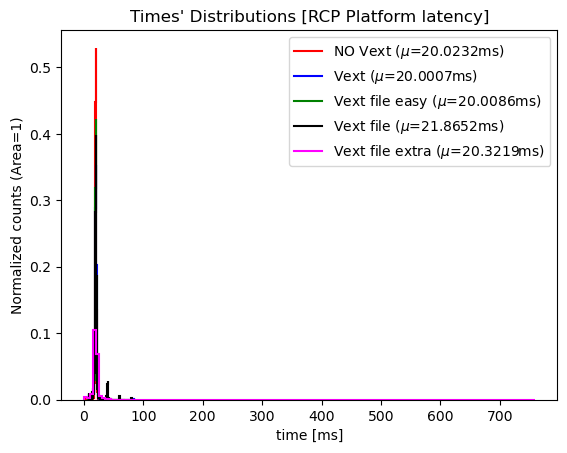

In [87]:
lw = 1.5
col1 = ['red', 'blue', 'green', 'black', 'magenta']
col2 = ['orange', 'azzure', 'light green', 'grey', 'pink']

def distrib_plots(ff, choosen_files):
    j = 0
    _ = plt.figure(ff+100)
    for i,name in enumerate(choosen_files):
        X = np.linspace(0,max(hist_centers[i,j,:]),500)
        _ = plt.stairs(hist_counts[i,j,:], hist_edges[i,j,:], color=col1[i], linewidth=lw, label=r'%s ($\mu$=%.4fms)'%(name,params[i,j,0]))
        #lab = r'%s : Fit ($\mu$=%.4fms)'%(labs[i],params[i,j,0])
        #_ = plt.plot(X, sp.pdf(X, *params[i,j,:]), color=col2[i], linestyle='--', linewidth=lw-0.5, label=lab)
    _ = plt.legend()
    _ = plt.ylabel('Normalized counts (Area=1)')
    _ = plt.xlabel('time [ms]')
    #_ = plt.xlim([10,30])
    _ = plt.title('Times\' Distributions [RCP Platform latency]')
    _ = plt.savefig(pathfigs+'rcp_Distrib_latenze_Plat.svg', bbox_inches='tight', format='svg')
    _ = plt.show(True)

distrib_plots(0, labels)

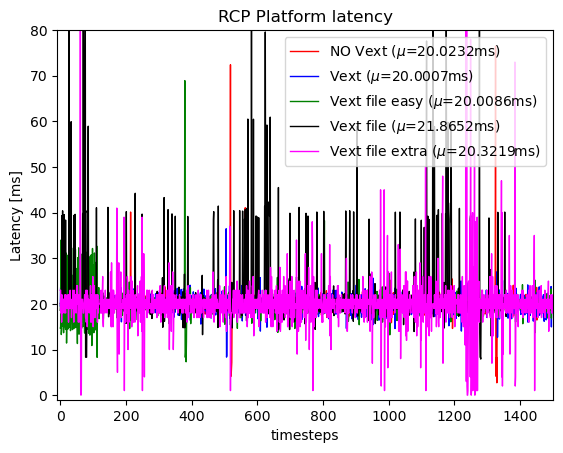

In [89]:
def lat_plots(ff, choosen_files):
    j = 0
    _ = plt.figure(ff+200)
    for i,name in enumerate(choosen_files):
        X = np.linspace(0,max(hist_centers[i,j,:]),500)
        _ = plt.plot(latency[i], color=col1[i], linewidth=1, label=r'%s ($\mu$=%.4fms)'%(name,params[i,j,0]))
        #lab = r'%s : Fit ($\mu$=%.4fms)'%(labs[i],params[i,j,0])
        #_ = plt.plot(X, sp.pdf(X, *params[i,j,:]), color=col2[i], linestyle='--', linewidth=lw-0.5, label=lab)
    _ = plt.legend()
    _ = plt.ylabel('Latency [ms]')
    _ = plt.xlabel('timesteps')
    _ = plt.xlim([-10,1500])
    _ = plt.ylim([-1,80])
    _ = plt.title('RCP Platform latency')
    _ = plt.savefig(pathfigs+'rcp_latenze_Plat.svg', bbox_inches='tight', format='svg')
    _ = plt.show(True)

lat_plots(0, labels)